# Classic model

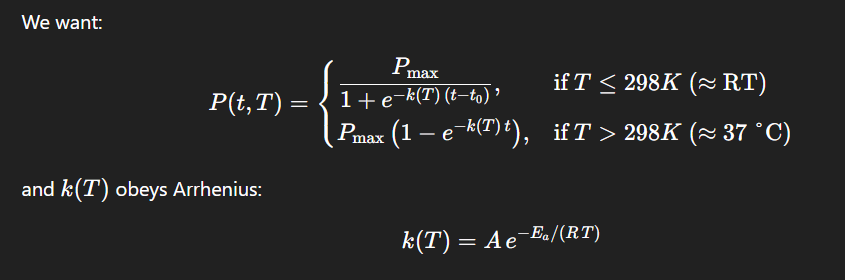

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [47]:
# --- Load your wide-format CSV ---
df_wide = pd.read_excel("all_time_temp.xlsx")

# Extract all experiment names automatically from column headers
samples = [col.split("_Time")[0] for col in df_wide.columns if "_Time" in col]

# Build dictionary {sample_name: sub-DataFrame}
datasets = {}
for s in samples:
    time_col = f"{s}_Time"
    temp_col = f"{s}_Temperature"
    subdf = df_wide[[time_col, temp_col]].copy()
    subdf.columns = ["Time (h)", "calibrated temperature (C)"]
    subdf = subdf.dropna().reset_index(drop=True)
    datasets[s] = subdf

print(" Loaded samples:", list(datasets.keys()))


 Loaded samples: ['M1_RT', 'M2_RT', 'M2_37C', 'M3_RT', 'M3_37C', 'M4_37C']


In [48]:

R = 8.314  # J/mol·K

# --- Cell 3: Metadata for each experiment ---

meta = pd.DataFrame({
    "Sample": ["M1_RT", "M2_RT", "M2_37C", "M3_RT", "M3_37C", "M4_37C"],
    "C_mM": [2.5, 2.18, 2.18, 1.2, 1.2, 1.6],
    "V_solution_mL": [6.0]*6,
    "V_head_mL": [4.0]*6,
    "Ea_Jmol": [19999.06, 19999.22, 93554.58,19997.88, 23583.23, 91914.18],  #check this
    "A_ph": [138.63, 178.49, 3.56e14, 252.38, 911.411, 2.45e14 ],  #check this
    "t0_h":[16.55, 62.77, 12.25, 29.25,7.16, 8.65],
    "Yield": [0.91, 0.756, 0.93, 0.902, 0.95, 0.97],
    "Model": ["logistic", "logistic", "first_order", "logistic", "first_order", "first_order"]
})

display(meta)










,Sample,C_mM,V_solution_mL,V_head_mL,Ea_Jmol,A_ph,t0_h,Yield,Model
0,M1_RT,2.50,6.0,4.0,19999.06,1.386300e+02,16.55,0.910,logistic
1,M2_RT,2.18,6.0,4.0,19999.22,1.784900e+02,62.77,0.756,logistic
2,M2_37C,2.18,6.0,4.0,93554.58,3.560000e+14,12.25,0.930,first_order
3,M3_RT,1.20,6.0,4.0,19997.88,2.523800e+02,29.25,0.902,logistic
4,M3_37C,1.20,6.0,4.0,23583.23,9.114110e+02,7.16,0.950,first_order
5,M4_37C,1.60,6.0,4.0,91914.18,2.450000e+14,8.65,0.970,first_order


✅ Global fit: A = 2.117e+02, Ea = 20.3 kJ/mol
   (Used 6 experiments)


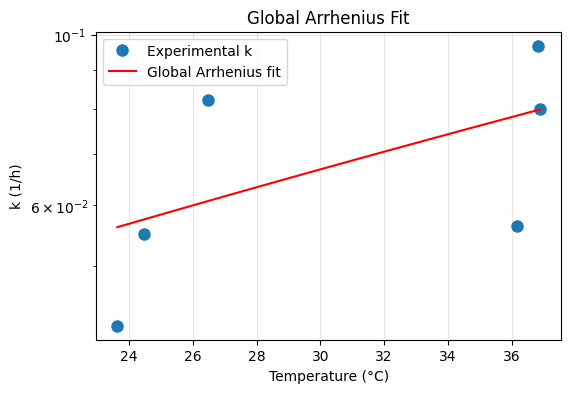

In [49]:
# --- Fit Global Arrhenius Parameters ---
from scipy.optimize import curve_fit

def arrhenius(T_K, A, Ea):
    """Arrhenius equation: k = A * exp(-Ea / RT)"""
    return A * np.exp(-Ea / (R * T_K))

# Prepare data for fitting
T_data = []
k_data = []

for _, row in meta.iterrows():
    # Get representative temperature
    sample_name = row['Sample']
    df_temp = datasets[sample_name]
    T_mean = df_temp["calibrated temperature (C)"].mean() + 273.15
    
    # Get k from metadata (mean k value from your fits)
    # Use the fitted k or A values you already have
    if row['Model'] == 'logistic':
        k_mean = row['A_ph'] * np.exp(-row['Ea_Jmol'] / (R * T_mean))
    else:
        k_mean = row['A_ph'] * np.exp(-row['Ea_Jmol'] / (R * T_mean))
    
    T_data.append(T_mean)
    k_data.append(k_mean)

T_data = np.array(T_data)
k_data = np.array(k_data)

# Fit global A and Ea
popt, pcov = curve_fit(arrhenius, T_data, k_data, p0=[1e6, 50000])
A_global, Ea_global = popt

print(f"✅ Global fit: A = {A_global:.3e}, Ea = {Ea_global/1000:.1f} kJ/mol")
print(f"   (Used {len(T_data)} experiments)")

# Plot to verify
plt.figure(figsize=(6,4))
plt.semilogy(T_data - 273.15, k_data, 'o', label='Experimental k', markersize=8)
T_plot = np.linspace(T_data.min(), T_data.max(), 100)
plt.semilogy(T_plot - 273.15, arrhenius(T_plot, A_global, Ea_global), 
             'r-', label='Global Arrhenius fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('k (1/h)')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Global Arrhenius Fit')
plt.show()

In [50]:
# --- Cell 4: Compute dynamic k(T) for each sample --- i.e the arrhenius K
R = 8.314  # J/mol·K

k_dynamic = {}

for s in datasets.keys():
    df = datasets[s].copy()
    meta_row = meta.loc[meta["Sample"] == s].iloc[0]
    
    # convert °C → K
    df["T_K"] = df["calibrated temperature (C)"] + 273.15
    
    # dynamic k(t) using Arrhenius
    A = meta_row["A_ph"]
    Ea = meta_row["Ea_Jmol"]
    df["k(1/h)"] = A * np.exp(-Ea / (R * df["T_K"]))
    
    k_dynamic[s] = df
    print(f" Computed k(T) for {s}: range = [{df['k(1/h)'].min():.3e}, {df['k(1/h)'].max():.3e}]")


 Computed k(T) for M1_RT: range = [4.078e-02, 4.394e-02]
 Computed k(T) for M2_RT: range = [5.323e-02, 5.731e-02]
 Computed k(T) for M2_37C: range = [5.452e-02, 5.725e-02]
 Computed k(T) for M3_RT: range = [7.694e-02, 8.961e-02]
 Computed k(T) for M3_37C: range = [9.603e-02, 9.704e-02]
 Computed k(T) for M4_37C: range = [7.856e-02, 8.373e-02]


In [51]:
# Pmax for each sample


Pmax_dict = {}

for s in meta["Sample"]:
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    # Convert concentration from mM → mol/L
    C_mol_L = m["C_mM"] * 1e-3
    
    # Convert volumes to liters and cubic meters
    V_sol_L = m["V_solution_mL"] * 1e-3
    V_head_L = m["V_head_mL"] * 1e-3
    V_head_m3 = V_head_L * 1e-3  # 1 L = 1e-3 m³
    
    # Use the mean temperature from your dynamic data
    df_temp = datasets[s]
    T_mean_K = (df_temp["calibrated temperature (C)"].mean() + 273.15)
    
    # Calculate moles of O₂ released
    n_mol = C_mol_L * V_sol_L * m["Yield"]
    
    # Ideal gas law: P = nRT / V
    Pmax_Pa = (n_mol * R * T_mean_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0
    
    Pmax_dict[s] = Pmax_kPa
    print(f"{s}: Pmax = {Pmax_kPa:.2f} kPa (T_mean = {T_mean_K:.2f} K)")



M1_RT: Pmax = 8.42 kPa (T_mean = 296.78 K)
M2_RT: Pmax = 6.12 kPa (T_mean = 297.62 K)
M2_37C: Pmax = 7.82 kPa (T_mean = 309.31 K)
M3_RT: Pmax = 4.04 kPa (T_mean = 299.62 K)
M3_37C: Pmax = 4.41 kPa (T_mean = 309.98 K)
M4_37C: Pmax = 6.00 kPa (T_mean = 310.04 K)


In [52]:
# --- Cell 6: Simulate P(t) for each sample --- (pressure at each time point)

from scipy.integrate import cumulative_trapezoid

results = {}

for s in datasets.keys():
    df = k_dynamic[s]
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    time = df["Time (h)"].values
    kT = df["k(1/h)"].values
    Pmax = Pmax_dict[s]
    
    if m["Model"] == "logistic":
        # Logistic growth: P = Pmax / (1 + exp(-∫k dt))
        t0 = m["t0_h"]
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax / (1 + np.exp(-K_int*(time - t0)))
        
    elif m["Model"] == "first_order":
        # First-order release: P = Pmax * (1 - exp(-∫k dt))
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax * (1 - np.exp(-K_int))
        
    else:
        raise ValueError(f"Unknown model type for {s}")
    
    df["P_predicted"] = P
    results[s] = df

    print(f" Simulated P(t) for {s} ({m['Model']})")


 Simulated P(t) for M1_RT (logistic)
 Simulated P(t) for M2_RT (logistic)
 Simulated P(t) for M2_37C (first_order)
 Simulated P(t) for M3_RT (logistic)
 Simulated P(t) for M3_37C (first_order)
 Simulated P(t) for M4_37C (first_order)


In [ ]:
# --- Cell 7: Plot ---
import matplotlib.pyplot as plt

for s, df in results.items():
    m = meta.loc[meta["Sample"] == s].iloc[0]
    plt.figure(figsize=(6,4))
    plt.plot(df["Time (h)"], df["P_predicted"], label=f"{s} ({m['Model']})", lw=2)
    plt.xlabel("Time (h)")
    plt.ylabel("Predicted Pressure / O₂ released (relative)")
    plt.title(f"Classical model prediction — {s}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# --- constants ---
R = 8.314  # J/mol·K

# --- helper to choose nearest kinetic parameters ---
def get_params_for_temp(temp_C, meta):
    """
    Select the nearest experiment's A and Ea from the meta DataFrame
    based on user temperature (Celsius).
    """
    # Define representative mean temperatures for each model
    # (You could also store actual mean T in meta if available)
    model_temp_map = {
        "logistic": 25.0,
        "first_order": 37.0
    }

    # Compute distance of user temperature from each model type
    d_logistic = abs(temp_C - model_temp_map["logistic"])
    d_first = abs(temp_C - model_temp_map["first_order"])

    # Choose the closest model type
    model_type = "logistic" if d_logistic < d_first else "first_order"

    # Get the row from your real meta table
    row = meta[meta["Model"] == model_type].iloc[0]
    A = row["A_ph"]
    Ea = row["Ea_Jmol"]
    return A, Ea, model_type




def simulate_classical(conc_mM, temp_C):
    # 1️⃣ Automatically choose parameters based on temperature
    A, Ea, model_choice = get_params_for_temp(temp_C, meta)
    
    if model_choice == "logistic":
        t0 = meta.loc[meta["Model"] == "logistic", "t0_h"].mean()
    else:
        t0 = 0 

    # 3️⃣ Fixed geometry
    V_sol_L = 0.006   # 6 mL solution
    V_head_L = 0.004  # 4 mL headspace
    Yield = 0.9

    # 4️⃣ Unit conversions
    C_mol_L = conc_mM * 1e-3
    V_head_m3 = V_head_L * 1e-3
    T_K = temp_C + 273.15
    
    # Warn about extrapolation
    if temp_C < 20 or temp_C > 40:
        print(f"⚠️ Extrapolating beyond tested range (20-40°C)")
    if conc_mM < 1.0 or conc_mM > 2.5:
        print(f"⚠️ Extrapolating beyond tested conc range (1.0-2.5 mM)")

    # 5️⃣ Calculate k with concentration dependence
    k_base = arrhenius(T_K, A_global, Ea_global)
    
    # ADD THIS: Concentration dependence (power law)
    C_ref = 2.0  # Reference concentration (mM) - middle of your range
    n_conc = 0.5  # Concentration order (adjust based on your data)
    k = k_base * (conc_mM / C_ref)**n_conc  # ← ADDED concentration dependence

    # 6️⃣ Compute Pmax in kPa
    n_mol = C_mol_L * V_sol_L * Yield
    Pmax_Pa = (n_mol * R * T_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0

    # 7️⃣ Simulate P(t)
    t = np.linspace(0, 250, 1000)   # extend to 250 h
    if model_choice == "logistic":
        P = Pmax_kPa / (1 + np.exp(-k * (t - t0)))  # removed k_vis
    else:
        P = Pmax_kPa * (1 - np.exp(-k * t))

    
    # 8️⃣ Convert Pressure → µmol O₂
    R_Latm = 0.082057  # L·atm/mol·K
    pressure_atm = P / 101.325  # convert kPa → atm
    o2_umol = ((pressure_atm * V_head_L) / (R_Latm * T_K)) * 1e6  # µmol O₂

    # optional ratio (for normalization if needed)
    ratio = V_sol_L / V_head_L

    # 9️⃣ Plot both Pressure and O₂ on two axes
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(t, P, lw=2, color="tab:blue", label="Pressure (kPa)")
    ax1.set_xlabel("Time (h)")
    ax1.set_ylabel("Pressure (kPa)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(t, o2_umol, lw=2, color="tab:red", linestyle="--", label="O₂ released (µmol)")
    ax2.set_ylabel("O₂ released (µmol)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title(f"Predicted P(t) and O₂(t) — {model_choice.capitalize()} model @ {temp_C:.1f}°C")
    fig.tight_layout()
    plt.show()

    # 10️⃣ Print key summary
    print(f"Model selected: {model_choice}")
    print(f"A = {A:.3e}, Ea = {Ea/1000:.1f} kJ/mol, t₀ = {t0:.2f} h")
    print(f"k(T) = {k:.3e} 1/h, Pmax = {Pmax_kPa:.2f} kPa")
    print(f"Predicted max O₂ = {max(o2_umol):.2f} µmol (ratio sol/head = {ratio:.2f})")
    
    # --- interactive sliders ---
interact(
    simulate_classical,
    conc_mM=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description="Conc (mM)"),
    temp_C=FloatSlider(value=25.0, min=20.0, max=45.0, step=0.5, description="Temp (°C)")
);


interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=5.0, min=0.5), FloatSlider(value=25.…

# To do (Monday deadline)

1. Add interpolation of temp and conc part
2. Derive the analytic correlation between ngas(t) ​​, [ANT-EPO] concentration, and Vheadspace/Vsol​.
3.Identify where this simple model performs well and where it breaks down (e.g., nonlinearity beyond certain ratios and concentrations).
4.Test how the model behaves when changing headspace or solution volume ratios (adaptively and not hard coded or random number – like we talked about last week).
5. Simulate different partial pressures or temperatures to show where the classical description stops being reliable.
6.Start a parameter sweep varying volume ratios, concentrations, and temperature (even theoretical values).
7. Summarize all results in a clear table and short plots in the presentation formation which you did earlier and analyze what holds, what breaks.

# Mention the fact tyhat different bounds were used for logistic for 1.2mM RT

it is to be noted that the k value should have a limit like it works welll from bound -.1 (see if there are different testuig technqiues for it) (previously i kept 1e6 as the bound for k but it didnt give good results, explore into this)

drawbacks :
1. Interpolation for temperature beyond the tested limited is unreliable: is there a fix for this with kinetic modelling? if no, what could be done?

# Prove empirically that kinetic models (first-order, logistic, Arrhenius–logistic) are insufficient to accurately estimate P(t,T) across time, temperature, and concentration variations.

# Different tests possible to show that the mathematical or kinetic modelling is failing:
1. Time-dependent residuals analysis : Show that the model systematically mispredicts certain time regions.
2. Multi-concentration comparison : Show that kinetic model parameters (especially k, Pmax, , t0) do not scale linearly or predictably with concentration.
3. Predictive extrapolation test : Show that the fitted model fails to extrapolate beyond training time or between temperature domains.
4. Overlay of experimental vs predicted curves (for all T, C) : Show mismatched shapes, Model lacks flexibility

# t0 vs conc at RT

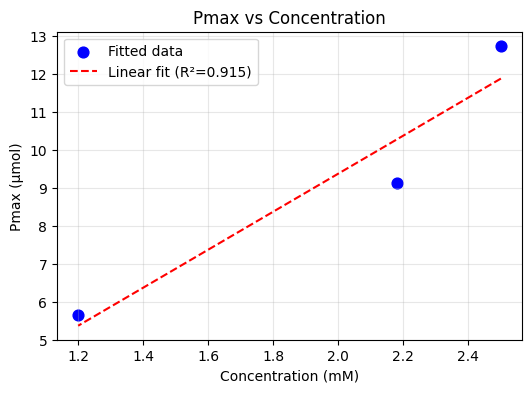

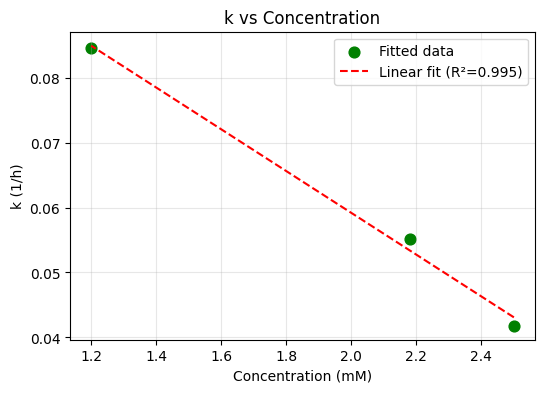

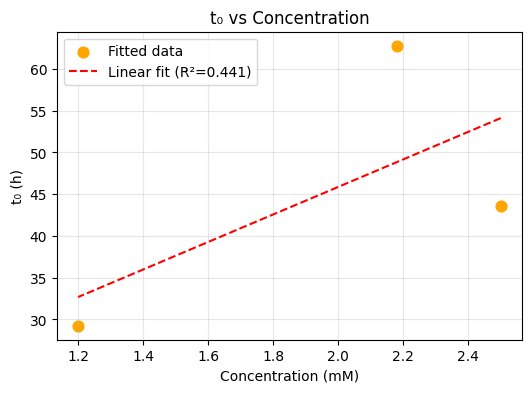

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# Example fitted parameters from your runs
# Replace with actual values from your logistic/Arrhenius fits
# ---------------------------
data = {
    "Sample": ["M1", "M2", "M3"],
    "Conc_mM": [2.5, 2.18, 1.2],
    "Pmax_umol": [12.744, 9.128, 5.65],
    "k_mean_1h": [0.0418, 0.0551, 0.0845],
    "t0_h": [43.60, 62.77, 29.25],
}

df = pd.DataFrame(data)

# ---------------------------
# Plot 1: Pmax vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["Pmax_umol"], s=60, c='b', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("Pmax (µmol)")
plt.title("Pmax vs Concentration")
# Linear fit test
model = LinearRegression().fit(df[["Conc_mM"]], df["Pmax_umol"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["Pmax_umol"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------
# Plot 2: k vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["k_mean_1h"], s=60, c='g', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("k (1/h)")
plt.title("k vs Concentration")
model = LinearRegression().fit(df[["Conc_mM"]], df["k_mean_1h"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["k_mean_1h"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------
# Plot 3: t0 vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["t0_h"], s=60, c='orange', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("t₀ (h)")
plt.title("t₀ vs Concentration")
model = LinearRegression().fit(df[["Conc_mM"]], df["t0_h"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["t0_h"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The middle concentration (2.18 mM) has the longest lag phase, which contradicts simple kinetic theory.

# t0 vs conc at 37C

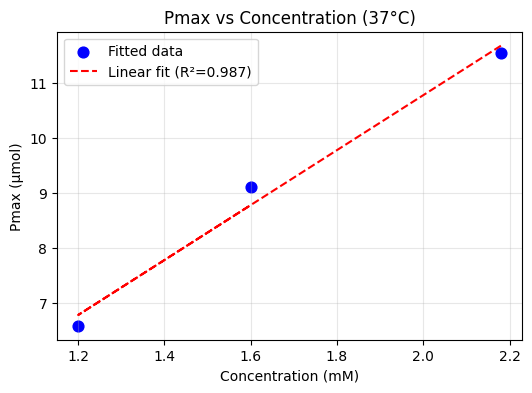

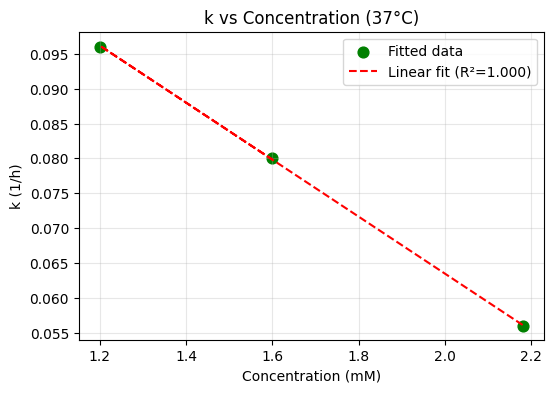

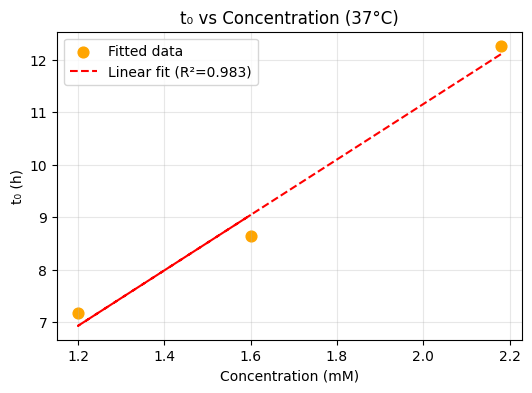

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------------------------------------
# Example fitted results at 37 °C (replace with your real fitted values)
# ---------------------------------------------------------
data_37C = {
    "Sample": ["M2", "M3", "M4"],
    "Conc_mM": [2.18, 1.2, 1.6],
    "Pmax_umol": [11.55, 6.58, 9.11],
    "k_mean_1h": [0.056, 0.096, 0.080077],
    "t0_h": [12.27, 7.17, 8.65]
}

df37 = pd.DataFrame(data_37C)

# ---------------------------------------------------------
# Plot 1: Pmax vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["Pmax_umol"], s=60, c='b', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("Pmax (µmol)")
plt.title("Pmax vs Concentration (37°C)")
# Linear regression
model = LinearRegression().fit(df37[["Conc_mM"]], df37["Pmax_umol"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["Pmax_umol"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Plot 2: k vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["k_mean_1h"], s=60, c='g', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("k (1/h)")
plt.title("k vs Concentration (37°C)")
model = LinearRegression().fit(df37[["Conc_mM"]], df37["k_mean_1h"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["k_mean_1h"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Plot 3: t0 vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["t0_h"], s=60, c='orange', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("t₀ (h)")
plt.title("t₀ vs Concentration (37°C)")
model = LinearRegression().fit(df37[["Conc_mM"]], df37["t0_h"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["t0_h"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Next plan : 
Train a small MLP (or even a Random Forest) on features:
[t, T, conc] → P(t)

Compare its RMSE and R2 against your logistic model.
Model prediction (classical vs ML) vs experiment.

